# Toy Inference From Run Directory

Interactive notebook version for continuing development.

Workflow:
1. Set `RUN_DIR` and toy physical inputs.
2. Load the engineered-feature v2 run through its refinement checkpoint and teacher metadata.
3. Build the five-column engineered feature matrix.
4. Run inference, rescale the A-normalized output to physical penetration, and plot mean plus `+/- 1 std`.

In [ ]:
from pathlib import Path

import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch


In [ ]:
# User config
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "MLP").exists() and PROJECT_ROOT.name == "MLP":
    PROJECT_ROOT = PROJECT_ROOT.parent

# New engineered-feature v2 refinement run. Its teacher metadata is resolved
# automatically from teacher_run_dir.txt; legacy 9-feature runs are intentionally
# not supported by this notebook anymore.
RUN_DIR = PROJECT_ROOT / "MLP" / "runs_mlp" / "distill_cdf_onset_v2_20260410_103413"


toy_raw = {
    "tilt_angle_radian": float(np.deg2rad(20.0)),
    "plumes": 10.0,
    "diameter_mm": 0.3,
    "injection_duration_us": 800.0,
    "injection_pressure_bar": 2000.0,
    # v2 uses physical ambient pressure and density to compute A_scale.
    # Keep chamber_pressure_bar as a compatibility alias for sanity checks.
    "ambient_pressure_bar_phys": 25.0,
    "chamber_pressure_bar": 25.0,
    "control_backpressure_bar": 4.0,
}

toy_n_points = 300
toy_time_ms = np.linspace(0.0, 5.0, toy_n_points, dtype=np.float32)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# 2D solver Macro 
t = 0.5 # ms
cone_angle = 20 # deg, change to a function in the future

cylinder_radius = 120 # mm
cylinder_height = 60 # mm

right_padding = 10 # mm
piston_height = 30 # mm

grid_size = 0.1 # mm

cylinder_head_offset = 50 # mm, improve to parametrized function later

assert cylinder_head_offset <= cylinder_height

# Keep mm -> grid conversion stable when grid_size is fractional (for example 0.1 mm).
def mm_to_grid_index(value_mm: float, mode: str = "round") -> int:
    scaled = float(value_mm) / float(grid_size)
    if mode == "round":
        return int(np.rint(scaled))
    if mode == "floor":
        return int(np.floor(scaled + 1e-9))
    if mode == "ceil":
        return int(np.ceil(scaled - 1e-9))
    raise ValueError(f"Unsupported mode: {mode!r}")

grid_width_px = mm_to_grid_index(cylinder_radius + right_padding)

# The canvas must cover the largest y coordinate used by the geometry.
grid_height_mm = cylinder_head_offset + cylinder_height
grid_height_px = mm_to_grid_index(grid_height_mm)


In [ ]:

x = np.arange(grid_width_px, dtype=float) * grid_size
y = np.arange(grid_height_px, dtype=float) * grid_size

X, Y = np.meshgrid(x, y, indexing="xy")


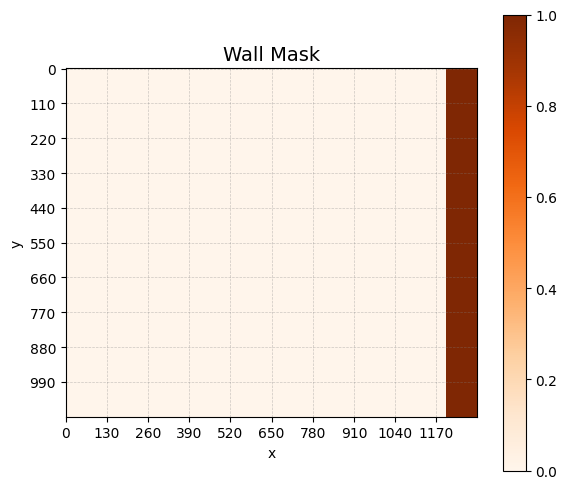

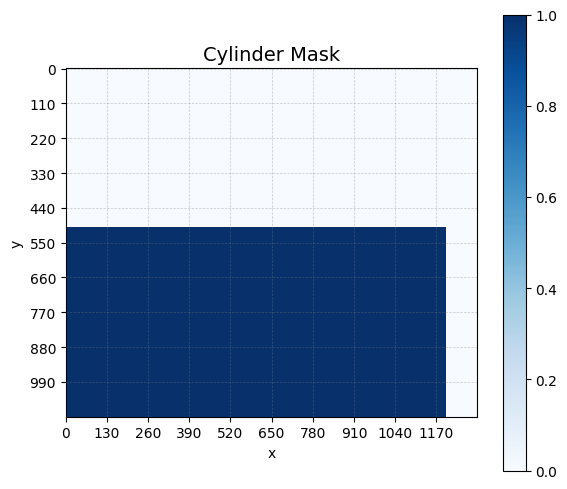

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

canvas = np.zeros((grid_height_px, grid_width_px))

wall_mask = np.zeros_like(canvas)
wall_mask[:, mm_to_grid_index(cylinder_radius):] = 1

cylinder_mask = np.zeros_like(canvas)
cylinder_mask[mm_to_grid_index(cylinder_head_offset):, :mm_to_grid_index(cylinder_radius)] = 1


def show_mask(mask, title, cmap="Blues"):
    h, w = mask.shape
    fig, ax = plt.subplots(figsize=(6, 6))

    im = ax.imshow(
        mask,
        cmap=cmap,
        # origin="lower",   # 比较像一般 x-y 坐标
        interpolation="none"
    )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    ax.set_xticks(np.arange(0, w, max(1, w // 10)))
    ax.set_yticks(np.arange(0, h, max(1, h // 10)))

    ax.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.4)
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()


show_mask(wall_mask, "Wall Mask", cmap="Oranges")
show_mask(cylinder_mask, "Cylinder Mask", cmap="Blues")



In [ ]:
mlp_module_dir = PROJECT_ROOT / "MLP"
v2_feature_dir = mlp_module_dir / "training"
for module_dir in (mlp_module_dir, v2_feature_dir):
    module_dir_str = str(module_dir)
    if module_dir_str not in sys.path:
        sys.path.insert(0, module_dir_str)

from engineered_feature_common import (
    TIME_FEATURE,
    build_dataset_registry,
    build_feature_matrix_np,
    infer_feature_family,
    load_run_artifacts,
)


def split_model_outputs(model_output: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor | None]:
    if model_output.shape[-1] < 2:
        raise ValueError(f"Expected at least 2 outputs, got shape {tuple(model_output.shape)}")
    mu_hat = model_output[..., :1]
    log_var_hat = model_output[..., 1:2]
    onset_logit = model_output[..., 2:3] if model_output.shape[-1] >= 3 else None
    return mu_hat, log_var_hat, onset_logit


def build_toy_feature_bundle(
    raw: dict[str, object],
    time_ms: np.ndarray | float,
    scaler_state: dict,
    feature_columns: list[str],
    time_feature: str,
    registry: dict,
) -> tuple[np.ndarray, np.ndarray, dict]:
    time_ms_arr = np.asarray(time_ms, dtype=np.float32)
    if time_ms_arr.ndim == 0:
        time_ms_arr = time_ms_arr.reshape(1)

    features_np, a_scale_np, canonical = build_feature_matrix_np(
        raw,
        time_ms_arr,
        scaler_state,
        feature_columns,
        registry,
        time_feature=time_feature,
    )
    return features_np, a_scale_np.reshape(-1), canonical


def predict_toy_physical(raw: dict[str, object], time_ms: np.ndarray | float) -> dict[str, object]:
    features_np, a_scale_np, canonical = build_toy_feature_bundle(
        raw=raw,
        time_ms=time_ms,
        scaler_state=scaler_state,
        feature_columns=feature_columns,
        time_feature=time_feature,
        registry=registry,
    )
    features = torch.as_tensor(features_np, dtype=torch.float32, device=DEVICE)
    a_scale = torch.as_tensor(a_scale_np.reshape(-1, 1), dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        model_output = model(features)
        mu_hat, log_var_hat, onset_logit = split_model_outputs(model_output)
        log_var_hat = torch.clamp(log_var_hat, min=-20.0, max=20.0)
        mu_physical = a_scale * mu_hat
        std_physical = a_scale * torch.exp(0.5 * log_var_hat)
        std_floor = float(train_config.get("std_clamp_min", 0.0))
        std_physical = torch.clamp(std_physical, min=std_floor)

    onset_prob_np = None
    if onset_logit is not None:
        onset_prob_np = torch.sigmoid(onset_logit).detach().cpu().numpy().reshape(-1)

    mu_np = mu_physical.detach().cpu().numpy().reshape(-1)
    std_np = std_physical.detach().cpu().numpy().reshape(-1)
    log_var_np = log_var_hat.detach().cpu().numpy().reshape(-1)
    return {
        "features_np": features_np,
        "a_scale_np": a_scale_np,
        "canonical": canonical,
        "mu_np": mu_np,
        "log_var_np": log_var_np,
        "std_np": std_np,
        "upper_np": mu_np + std_np,
        "lower_np": mu_np - std_np,
        "onset_prob_np": onset_prob_np,
    }


In [ ]:
registry = build_dataset_registry(PROJECT_ROOT / "test_matrix_json")
artifacts = load_run_artifacts(RUN_DIR, device=DEVICE)

train_config = artifacts.train_config
scaler_state = artifacts.scaler_state
model = artifacts.model
model_path = artifacts.model_path

feature_columns = list(train_config["feature_columns"])
time_feature = str(train_config.get("time_feature", TIME_FEATURE))
feature_family = infer_feature_family(feature_columns)
if feature_family != "engineered_v2":
    raise RuntimeError(
        "impingement_prediction.ipynb has been migrated to engineered-feature v2 only; "
        f"got feature family {feature_family!r}."
    )

output_dim = int(train_config.get("output_dim", 2))
HAS_ONSET_HEAD = output_dim >= 3

from ood_sanity import concise_warning_text, format_sanity_report, load_cdf_empirical_support, check_input_sanity

support = load_cdf_empirical_support(PROJECT_ROOT, split_filter="clean")
sanity_report = check_input_sanity(toy_raw, support)
sanity_warning_text = concise_warning_text(sanity_report, max_lines=4)

print(format_sanity_report(sanity_report))

teacher_run_dir = train_config.get("teacher_run_dir", "self-contained run")
print(f"RUN_DIR: {artifacts.run_dir.resolve()}")
print("Run kind: engineered-feature v2 refinement" if train_config.get("stage") == "refinement" else "Run kind: engineered-feature v2")
print(f"Teacher metadata: {teacher_run_dir}")
print(f"Model checkpoint: {Path(model_path).name}")
print(f"Device: {DEVICE}")
print(f"Feature columns: {feature_columns}")
print(f"Feature dimension: {len(feature_columns)}")
print(f"Output dimension: {output_dim}")
print(f"Onset head enabled: {HAS_ONSET_HEAD}")


Sanity check severity: strong
OOD warning: True
Exact combo match: False
Support source: C:\Users\Jiang\Documents\Mie_Postprocessing_Py\MLP\figures\fit_bias_audit_cdf\cdf_plume_audit.csv
Warnings:
- diameter_mm=0.3 is outside empirical support (z=-5.37, range=[0.333, 0.384]).
- Condition combination not observed in training support: injection_pressure_bar=2000, chamber_pressure_bar=25, control_backpressure_bar=4.
Nearest seen conditions:
- injection_pressure_bar=2000, chamber_pressure_bar=15, control_backpressure_bar=4 (distance=0.872)
- injection_pressure_bar=2200, chamber_pressure_bar=35, control_backpressure_bar=4 (distance=1.056)
- injection_pressure_bar=2200, chamber_pressure_bar=15, control_backpressure_bar=4 (distance=1.056)
RUN_DIR: C:\Users\Jiang\Documents\Mie_Postprocessing_Py\MLP\runs_mlp\distill_cdf_onset_v2_20260410_103413
Run kind: engineered-feature v2 refinement
Teacher metadata: C:\Users\Jiang\Documents\Mie_Postprocessing_Py\MLP\runs_mlp\stage2_engineered_nll_a_only_20

In [ ]:
prediction = predict_toy_physical(toy_raw, toy_time_ms)
toy_features_np = prediction["features_np"]
toy_a_scale_np = prediction["a_scale_np"]
toy_canonical = prediction["canonical"]
toy_mu_np = prediction["mu_np"]
toy_log_var_np = prediction["log_var_np"]
toy_std_np = prediction["std_np"]
toy_upper_np = prediction["upper_np"]
toy_lower_np = prediction["lower_np"]
toy_onset_prob_np = prediction["onset_prob_np"]

print("Toy inference completed with feature shape:", toy_features_np.shape)
print("Expected feature dimension:", len(feature_columns))
print("Feature family:", feature_family)
print("A_scale range:", float(np.min(toy_a_scale_np)), float(np.max(toy_a_scale_np)))
print("Canonical raw state:", toy_canonical)
print("Predicted std range:", float(np.min(toy_std_np)), float(np.max(toy_std_np)))
if toy_onset_prob_np is not None:
    print("Predicted onset probability range:", float(np.min(toy_onset_prob_np)), float(np.max(toy_onset_prob_np)))


Toy inference completed with feature shape: (300, 5)
Expected feature dimension: 5
Feature family: engineered_v2
A_scale range: 1.5833629369735718 1.5833629369735718
Canonical raw state: {'tilt_angle_radian': 0.3490658503988659, 'plumes': 10.0, 'diameter_mm': 0.3, 'injection_duration_us': 800.0, 'injection_pressure_bar': 2000.0, 'control_backpressure_bar': 4.0, 'ambient_pressure_bar_phys': 25.0, 'ambient_density_kg_m3': 28.28054298642534, 'chamber_state_source': 'physical_pressure_direct', 'delta_pressure_bar_phys': 1975.0, 'A_scale': 1.5833629063007777, 'log_A': 0.4595510068676638}
Predicted std range: 1.4964005947113037 12.174918174743652
Predicted onset probability range: 0.11190889030694962 0.9999969005584717


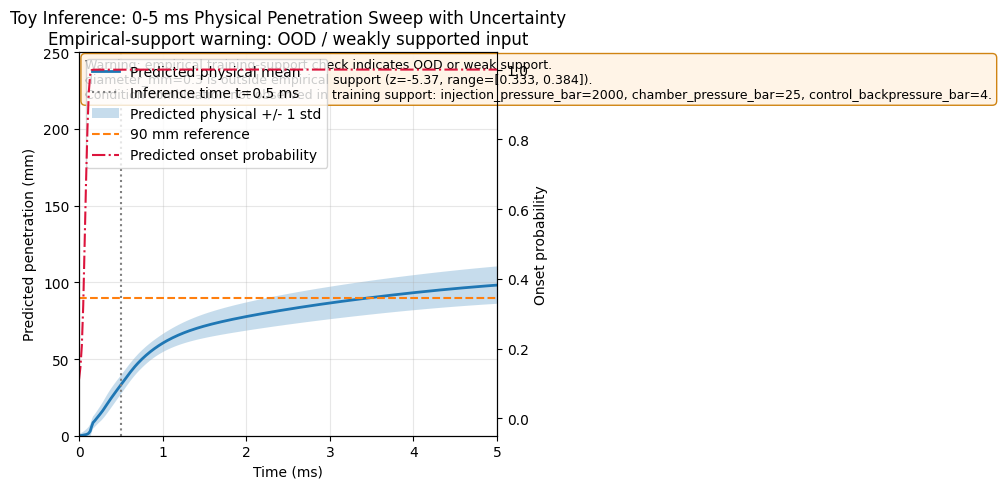

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(toy_time_ms, toy_mu_np, linewidth=2, label="Predicted physical mean")
ax.axvline(t, color="gray", linestyle=":", label=f"Inference time t={t} ms")
ax.fill_between(toy_time_ms, toy_lower_np, toy_upper_np, alpha=0.25, label="Predicted physical +/- 1 std")
ax.plot(toy_time_ms, 90 * np.ones_like(toy_time_ms), linestyle="--", label="90 mm reference")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Predicted penetration (mm)")
title = "Toy Inference: 0-5 ms Physical Penetration Sweep with Uncertainty"
if sanity_report["is_ood"]:
    title += "\nEmpirical-support warning: OOD / weakly supported input"
ax.set_title(title)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 250)
ax.set_xlim(0, 5)

if toy_onset_prob_np is not None:
    ax_onset = ax.twinx()
    ax_onset.plot(
        toy_time_ms,
        toy_onset_prob_np,
        color="crimson",
        linestyle="-.",
        linewidth=1.5,
        label="Predicted onset probability",
    )
    ax_onset.set_ylabel("Onset probability")
    ax_onset.set_ylim(-0.05, 1.05)
    handles_left, labels_left = ax.get_legend_handles_labels()
    handles_right, labels_right = ax_onset.get_legend_handles_labels()
    ax.legend(handles_left + handles_right, labels_left + labels_right, loc="upper left")
else:
    ax.legend()

bbox_props = dict(boxstyle="round,pad=0.35", facecolor="#fff4e5", edgecolor="#cc7a00", alpha=0.92)
ax.text(
    0.015,
    0.985,
    sanity_warning_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    bbox=bbox_props,
)

plt.tight_layout()
plt.show()


In [ ]:
# ========================================
# Calculate the physical penetration and log variance at a certain time point
# ========================================
prediction = predict_toy_physical(toy_raw, t)
toy_features_np = prediction["features_np"]
toy_a_scale_np = prediction["a_scale_np"]
toy_canonical = prediction["canonical"]
toy_mu_np = prediction["mu_np"]
toy_log_var_np = prediction["log_var_np"]
toy_std_np = prediction["std_np"]
toy_upper_np = prediction["upper_np"]
toy_lower_np = prediction["lower_np"]
toy_onset_prob_np = prediction["onset_prob_np"]

print(f"Predicted physical penetration mean at t={t} ms:", float(toy_mu_np.item()))
print(f"Predicted physical penetration std at t={t} ms:", float(toy_std_np.item()))
print(f"A_scale at t={t} ms:", float(toy_a_scale_np.item()))
print("Canonical raw state:", toy_canonical)
if toy_onset_prob_np is not None:
    print(f"Predicted onset probability at t={t} ms:", float(toy_onset_prob_np.item()))


Predicted physical penetration mean at t=0.5 ms: 33.12033462524414
Predicted physical penetration std at t=0.5 ms: 6.12138557434082
A_scale at t=0.5 ms: 1.5833629369735718
Canonical raw state: {'tilt_angle_radian': 0.3490658503988659, 'plumes': 10.0, 'diameter_mm': 0.3, 'injection_duration_us': 800.0, 'injection_pressure_bar': 2000.0, 'control_backpressure_bar': 4.0, 'ambient_pressure_bar_phys': 25.0, 'ambient_density_kg_m3': 28.28054298642534, 'chamber_state_source': 'physical_pressure_direct', 'delta_pressure_bar_phys': 1975.0, 'A_scale': 1.5833629063007777, 'log_A': 0.4595510068676638}
Predicted onset probability at t=0.5 ms: 0.9996975660324097


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


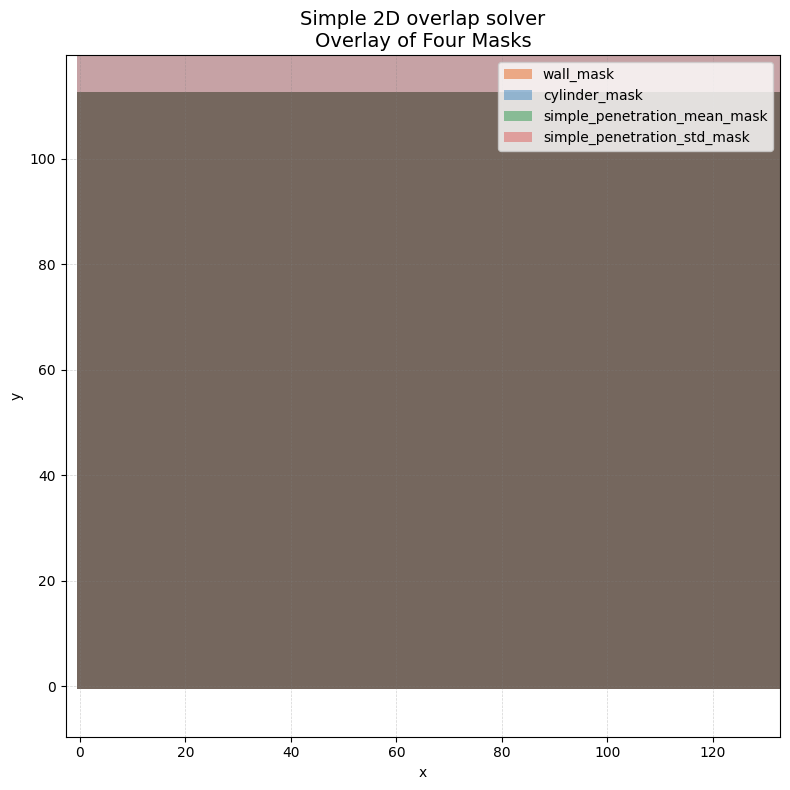

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Draw toy masks
tilt = toy_raw["tilt_angle_radian"]
x_factor = np.cos(tilt)
y_factor = np.sin(tilt)

penetration_x_mean = toy_mu_np.item() * x_factor
penetration_y_mean = toy_mu_np.item() * y_factor 

penetration_x_1std = toy_upper_np.item() * x_factor
penetration_y_1std = toy_upper_np.item() * y_factor

# 注意: imshow 对应 mask[y, x]，所以 shape / slice 都是 [H, W] = [y, x]
mean_x = min(canvas.shape[1], max(0, mm_to_grid_index(penetration_x_mean, mode="floor")))
mean_y = min(canvas.shape[0], max(0, mm_to_grid_index(penetration_y_mean, mode="floor")))

std_x = min(canvas.shape[1], max(0, mm_to_grid_index(penetration_x_1std, mode="floor")))
std_y = min(canvas.shape[0], max(0, mm_to_grid_index(penetration_y_1std, mode="floor")))

simple_penetration_mean_mask = np.zeros_like(canvas)
simple_penetration_mean_mask[:mean_y, :mean_x] = 1.0

simple_penetration_std_mask = np.zeros_like(canvas)
simple_penetration_std_mask[:std_y, :std_x] = 1.0

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(wall_mask, cmap="Oranges", origin="lower", interpolation="none", alpha=0.45)
ax.imshow(cylinder_mask, cmap="Blues", origin="lower", interpolation="none", alpha=0.45)
ax.imshow(simple_penetration_mean_mask, cmap="Greens", origin="lower", interpolation="none", alpha=0.50)
ax.imshow(simple_penetration_std_mask, cmap="Reds", origin="lower", interpolation="none", alpha=0.35)

h, w = canvas.shape
ax.set_title("Simple 2D overlap solver\nOverlay of Four Masks", fontsize=14)
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.35)

legend_handles = [
    Patch(facecolor=plt.cm.Oranges(0.7), edgecolor="none", alpha=0.45, label="wall_mask"),
    Patch(facecolor=plt.cm.Blues(0.7), edgecolor="none", alpha=0.45, label="cylinder_mask"),
    Patch(facecolor=plt.cm.Greens(0.7), edgecolor="none", alpha=0.50, label="simple_penetration_mean_mask"),
    Patch(facecolor=plt.cm.Reds(0.7), edgecolor="none", alpha=0.35, label="simple_penetration_std_mask"),
]
ax.legend(handles=legend_handles, loc="upper right")
ax.axis("equal")
ax.set_xlim(0, cylinder_radius + right_padding)
ax.set_ylim(0, grid_height_mm)
plt.tight_layout()
plt.show()


In [ ]:
simple_wall_collision = (simple_penetration_mean_mask == 1) & (wall_mask == 1)
print("Simple wall collision area (mm^2):", np.sum(simple_wall_collision) * (grid_size ** 2))
simple_cylinder_collision = (cylinder_mask == 1) & (simple_penetration_mean_mask == 1)
print("Simple cylinder collision area (mm^2):", np.sum(simple_cylinder_collision) * (grid_size ** 2))

Simple wall collision area (mm^2): 0.0
Simple cylinder collision area (mm^2): 0.0


In [ ]:
simple_wall_collision_std = (simple_penetration_std_mask == 1) & (wall_mask == 1)
print("Simple wall collision area with +1 std length (mm^2):", np.sum(simple_wall_collision_std) * (grid_size ** 2))
simple_cylinder_collision_std = (cylinder_mask == 1) & (simple_penetration_std_mask == 1)
print("Simple cylinder collision area with +1 std length (mm^2):", np.sum(simple_cylinder_collision_std) * (grid_size ** 2))

Simple wall collision area with +1 std length (mm^2): 0.0
Simple cylinder collision area with +1 std length (mm^2): 0.0


In [ ]:
def gaussian_distribution(x, sigma, mu):
    return 1/(sigma*np.sqrt(2*np.pi))*np.exp(-0.5*(x-mu)**2/sigma**2)


In [ ]:
# mean and std
mu = toy_mu_np.item()
sigma = toy_std_np.item()


In [ ]:
# mean penetration * tan(half cone angle) = mean plume width (approximately)
# this width to half plume width, assume to be 3 sigma_y, which has cdf = 99.7% for normal distribution, which is close to the common definition of plume width
width_y = mu*np.tan(np.deg2rad(cone_angle / 2))
sigma_y = width_y / 3
mu_y = 0

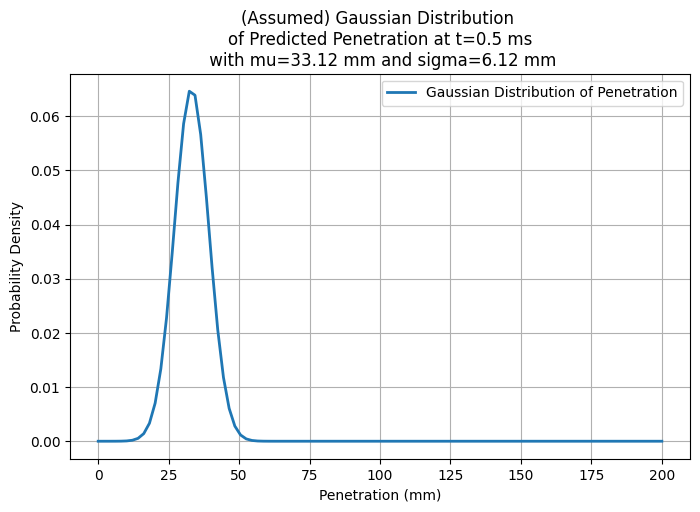

In [ ]:
x1 = np.linspace(0,200, 100)
y1 = gaussian_distribution(x1, sigma, mu)
plt.figure(figsize=(8, 5))
plt.plot(x1, y1, linewidth=2, label="Gaussian Distribution of Penetration")
plt.xlabel("Penetration (mm)")
plt.ylabel("Probability Density")
plt.title(f"(Assumed) Gaussian Distribution \nof Predicted Penetration at t={t} ms\n with mu={mu:.2f} mm and sigma={sigma:.2f} mm")
plt.legend()
plt.grid()
plt.show()


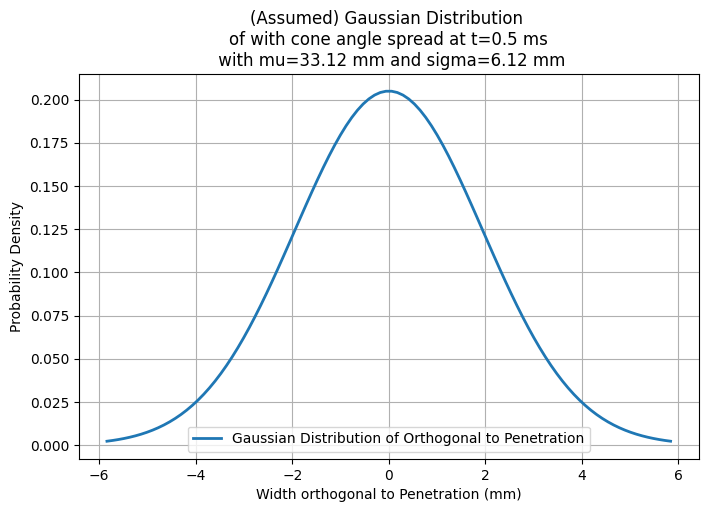

In [ ]:
x2 = np.linspace(mu_y-3*sigma_y, mu_y+3*sigma_y, 100)
y2 = gaussian_distribution(x2, sigma_y, mu_y)
plt.figure(figsize=(8, 5))
plt.plot(x2, y2, linewidth=2, label="Gaussian Distribution of Orthogonal to Penetration")
plt.xlabel("Width orthogonal to Penetration (mm)")
plt.ylabel("Probability Density")
plt.title(f"(Assumed) Gaussian Distribution \nof with cone angle spread at t={t} ms\n with mu={mu:.2f} mm and sigma={sigma:.2f} mm")
plt.legend()
plt.grid()
plt.show()

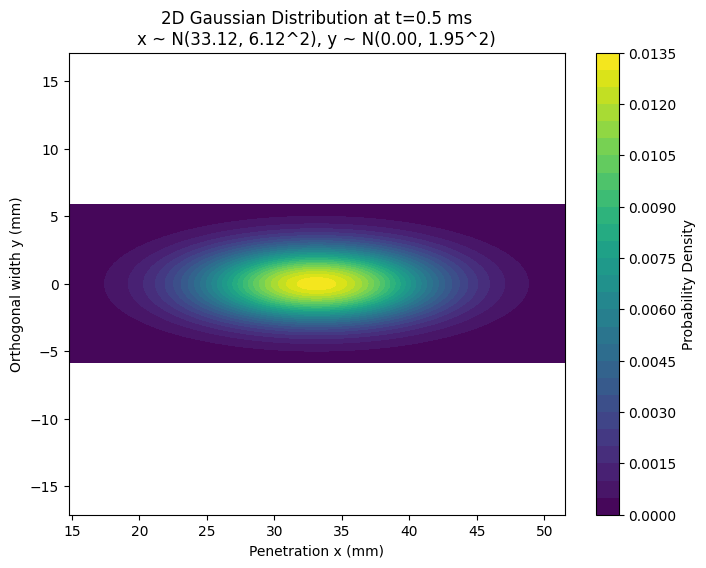

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_distribution(x, sigma, mu):
    return 1.0 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# 1D ranges
x1 = np.linspace(mu - 3*sigma, mu + 3*sigma, 200)
y1 = np.linspace(mu_y - 3*sigma_y, mu_y + 3*sigma_y, 200)

# 2D grid
X, Y = np.meshgrid(x1, y1)

# Independent 2D Gaussian
Z = gaussian_distribution(X, sigma, mu) * gaussian_distribution(Y, sigma_y, mu_y)

plt.figure(figsize=(8, 6))
cp = plt.contourf(X, Y, Z, levels=30, cmap="viridis")
plt.colorbar(cp, label="Probability Density")
plt.xlabel("Penetration x (mm)")
plt.ylabel("Orthogonal width y (mm)")
plt.title(
    f"2D Gaussian Distribution at t={t} ms\n"
    f"x ~ N({mu:.2f}, {sigma:.2f}^2), y ~ N({mu_y:.2f}, {sigma_y:.2f}^2)"
)
plt.axis("equal")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_2d_rotated(X, Y, x0, y0, sigma_axis, sigma_ortho, theta):
    c = np.cos(theta)
    s = np.sin(theta)

    dx = X - x0
    dy = Y - y0

    # world -> local spray coordinates
    u =  c * dx + s * dy
    v = -s * dx + c * dy

    pdf = np.exp(
        -0.5 * ((u / sigma_axis) ** 2 + (v / sigma_ortho) ** 2)
    ) / (2.0 * np.pi * sigma_axis * sigma_ortho)

    return pdf

# grid in physical coordinates, shape must match masks: [H, W] = [y, x]
x = np.arange(canvas.shape[1], dtype=float) * grid_size
y = np.arange(canvas.shape[0], dtype=float) * grid_size
X, Y = np.meshgrid(x, y, indexing="xy")

theta = toy_raw["tilt_angle_radian"]

# center of Gaussian in world coordinates
x0 = penetration_x_mean
y0 = penetration_y_mean

# along spray axis
sigma_axis = toy_std_np.item()

# orthogonal spread
# if you already have sigma_y, use it directly
sigma_ortho = sigma_y

pdf_2d = gaussian_2d_rotated(
    X, Y,
    x0=x0,
    y0=y0,
    sigma_axis=sigma_axis,
    sigma_ortho=sigma_ortho,
    theta=theta,
)

# normalize on discrete grid so total probability ~= 1
pdf_2d /= (pdf_2d.sum() * grid_size * grid_size)

extent = [x.min(), x.max() + grid_size, y.min(), y.max() + grid_size]


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


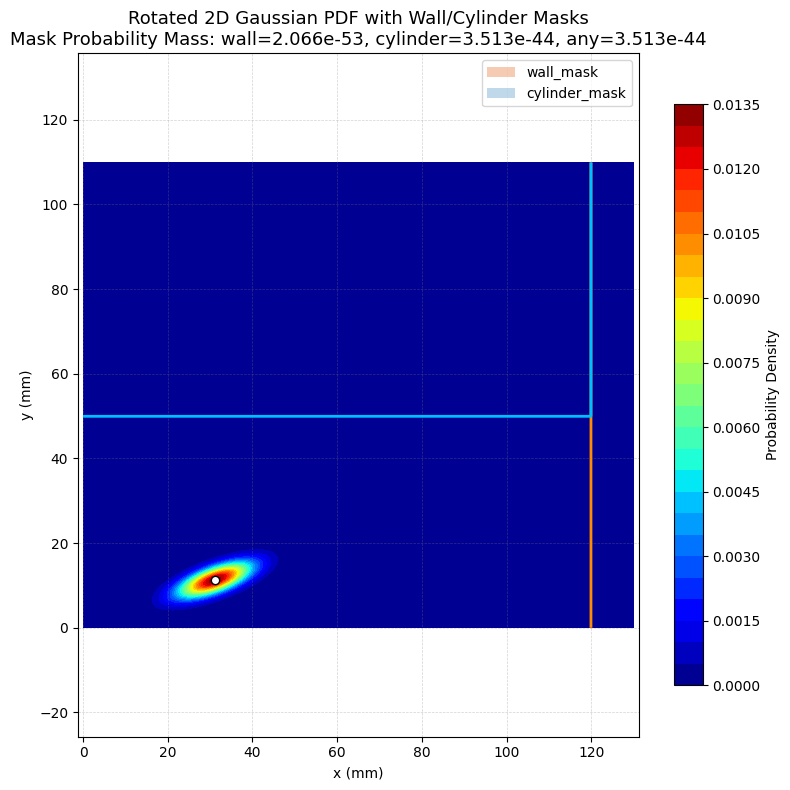

In [ ]:
from matplotlib.patches import Patch

p_wall = np.sum(pdf_2d * wall_mask) * (grid_size ** 2)
p_cylinder = np.sum(pdf_2d * cylinder_mask) * (grid_size ** 2)
p_any = np.sum(pdf_2d * np.maximum(wall_mask, cylinder_mask)) * (grid_size ** 2)

fig, ax = plt.subplots(figsize=(8, 8))
contour = ax.contourf(X, Y, pdf_2d, levels=30, cmap="jet")
wall_overlay = np.ma.masked_where(wall_mask == 0, wall_mask)
cylinder_overlay = np.ma.masked_where(cylinder_mask == 0, cylinder_mask)


ax.contour(X, Y, wall_mask, levels=[0.5], colors="darkorange", linewidths=2)
ax.contour(X, Y, cylinder_mask, levels=[0.5], colors="deepskyblue", linewidths=2)


ax.plot(x0, y0, "wo", markersize=6, markeredgecolor="k", label="Gaussian center")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_title(
    "Rotated 2D Gaussian PDF with Wall/Cylinder Masks\n"
    f"Mask Probability Mass: wall={p_wall:.3e}, cylinder={p_cylinder:.3e}, any={p_any:.3e}",
    fontsize=13,
)
ax.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.35)
ax.axis("equal")
ax.set_xlim(0, cylinder_radius + right_padding)
ax.set_ylim(0, grid_height_mm)

ax.imshow(
    wall_overlay,
    cmap="Oranges",
    origin="lower",
    extent=extent,
    alpha=0.18,
    interpolation="none",
    vmin=0,
    vmax=1,
)

ax.imshow(
    cylinder_overlay,
    cmap="Blues",
    origin="lower",
    extent=extent,
    alpha=0.18,
    interpolation="none",
    vmin=0,
    vmax=1,
)
legend_handles = [
    Patch(facecolor=plt.cm.Oranges(0.7), edgecolor="none", alpha=0.30, label="wall_mask"),
    Patch(facecolor=plt.cm.Blues(0.7), edgecolor="none", alpha=0.30, label="cylinder_mask"),
]
ax.legend(handles=legend_handles, loc="upper right")

cbar = plt.colorbar(contour, ax=ax, shrink=0.85)
cbar.set_label("Probability Density")

plt.tight_layout()
plt.show()


In [ ]:
print("Wall mask probability mass:", p_wall)
print("Cylinder mask probability mass:", p_cylinder)
print("Any collision probability mass:", p_any)


Wall mask probability mass: 2.0660963587473056e-53
Cylinder mask probability mass: 3.51275682255795e-44
Any collision probability mass: 3.5127568246240456e-44


In [ ]:
# Piston Head Design A
from piston.design_A import (
    build_piston_design_a_components,
    piston_design_A,
    quarter_of_a_circle_complement_mask,
)

piston_design_a_params = {
    "r_bore": cylinder_radius,
    "r_outer_bowl": 100.0,
    "r_topland": 5.0,
    "r_ring": 15.0,
    "r_inner_bowl": 80.0,
    "r_lip": 15.0,
    "r_floor": 5.0,
    "r_center_circle": 0.0,
    "h_vertical": 10.0,
    "piston_height": piston_height,
    "cylinder_head_offset": cylinder_head_offset,
}

piston_design_a_components = build_piston_design_a_components(
    canvas,
    grid_size,
    **piston_design_a_params,
)
piston_design_a_mask_from_module = piston_design_A(
    canvas,
    grid_size,
    **piston_design_a_params,
)

print("Design A mask shape:", piston_design_a_mask_from_module.shape)
print("Design A mask area (mm^2):", float(piston_design_a_mask_from_module.sum() * grid_size ** 2))


ModuleNotFoundError: No module named 'piston'

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(piston_design_a_components["base_mask"], origin="lower")
axes[0].set_title("Base polygons")
axes[1].imshow(piston_design_a_components["after_lip"], origin="lower")
axes[1].set_title("After lip cut")
axes[2].imshow(piston_design_a_mask_from_module, origin="lower")
axes[2].set_title("Design A final mask")
for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
plt.tight_layout()
plt.show()


In [ ]:
# Notebook-side manual reconstruction for parity check
piston_design_a_manual_base = np.zeros_like(canvas, dtype=np.uint8)

trapezoid_points_px_manual = np.rint(
    piston_design_a_components["trapezoid_points_mm"] / grid_size
).astype(np.int32)
trapezoid_points_px_manual[:, 0] = np.clip(trapezoid_points_px_manual[:, 0], 0, piston_design_a_manual_base.shape[1] - 1)
trapezoid_points_px_manual[:, 1] = np.clip(trapezoid_points_px_manual[:, 1], 0, piston_design_a_manual_base.shape[0] - 1)
cv2.fillPoly(piston_design_a_manual_base, [trapezoid_points_px_manual], color=1)

rectangle_points_px_manual = np.rint(
    piston_design_a_components["rectangle_points_mm"] / grid_size
).astype(np.int32)
rectangle_points_px_manual[:, 0] = np.clip(rectangle_points_px_manual[:, 0], 0, piston_design_a_manual_base.shape[1] - 1)
rectangle_points_px_manual[:, 1] = np.clip(rectangle_points_px_manual[:, 1], 0, piston_design_a_manual_base.shape[0] - 1)
cv2.fillPoly(piston_design_a_manual_base, [rectangle_points_px_manual], color=1)

qt_mask_1_manual = quarter_of_a_circle_complement_mask(
    canvas,
    grid_size,
    (piston_design_a_params["r_inner_bowl"], piston_design_a_params["cylinder_head_offset"] + piston_design_a_params["piston_height"] - piston_design_a_params["r_floor"]),
    piston_design_a_params["r_floor"],
    loc="top_right",
    negative_mask=False,
)
qt_mask_2_manual = quarter_of_a_circle_complement_mask(
    canvas,
    grid_size,
    (piston_design_a_params["r_outer_bowl"], piston_design_a_params["cylinder_head_offset"] + piston_design_a_params["r_lip"]),
    piston_design_a_params["r_lip"],
    loc="bottom_left",
    negative_mask=True,
)
qt_mask_3_manual = quarter_of_a_circle_complement_mask(
    canvas,
    grid_size,
    (piston_design_a_params["r_bore"] - piston_design_a_params["r_topland"], piston_design_a_params["cylinder_head_offset"] + piston_design_a_params["r_topland"]),
    piston_design_a_params["r_topland"],
    loc="bottom_right",
    negative_mask=True,
)

piston_design_a_manual_after_floor = piston_design_a_manual_base.astype(bool) | qt_mask_1_manual
piston_design_a_manual_after_lip = piston_design_a_manual_after_floor & qt_mask_2_manual
piston_design_a_manual_final = piston_design_a_manual_after_lip & qt_mask_3_manual


In [ ]:
np.testing.assert_array_equal(
    trapezoid_points_px_manual,
    piston_design_a_components["trapezoid_points_px"],
)
np.testing.assert_array_equal(
    rectangle_points_px_manual,
    piston_design_a_components["rectangle_points_px"],
)
np.testing.assert_array_equal(
    piston_design_a_manual_base.astype(bool),
    piston_design_a_components["base_mask"],
)
np.testing.assert_array_equal(qt_mask_1_manual.astype(bool), piston_design_a_components["qt_mask_1"])
np.testing.assert_array_equal(qt_mask_2_manual.astype(bool), piston_design_a_components["qt_mask_2"])
np.testing.assert_array_equal(qt_mask_3_manual.astype(bool), piston_design_a_components["qt_mask_3"])
np.testing.assert_array_equal(piston_design_a_manual_after_floor, piston_design_a_components["after_floor"])
np.testing.assert_array_equal(piston_design_a_manual_after_lip, piston_design_a_components["after_lip"])
np.testing.assert_array_equal(piston_design_a_manual_final, piston_design_a_components["final_mask"])
np.testing.assert_array_equal(piston_design_a_manual_final, piston_design_a_mask_from_module)

print("Notebook reconstruction matches piston.design_A module output exactly.")
print("Final occupied pixels:", int(piston_design_a_mask_from_module.sum()))


In [ ]:
design_a_diff = np.logical_xor(piston_design_a_manual_final, piston_design_a_mask_from_module)
print("Design A diff pixel count:", int(design_a_diff.sum()))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(piston_design_a_manual_final, origin="lower")
axes[0].set_title("Notebook reconstruction")
axes[1].imshow(piston_design_a_mask_from_module, origin="lower")
axes[1].set_title("Module output")
axes[2].imshow(design_a_diff, origin="lower", cmap="Reds")
axes[2].set_title("XOR diff")
for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
plt.tight_layout()
plt.show()
